## 2025-09-15: CNN Exploration

### Authors
* Nicole Tin (nicole@velexi.com)


### Overview
This Jupyter notebook is intended to explore


### Key Results

The key results of this experiment are ...

### Future Ideas
* 


### Experiment Parameters

In [1]:
# --- Experiment parameters

# Name of experiment. Used for MLflow experiment name, output files, etc.
experiment_name = "NT-M4-ResNet50-Torchvision"

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'

image_folder = '/images_processed/'
features_folder = '/features-2025-02-24/'
csv_file = '/metadata.csv'
segmentation_folder = '/segmentation_npys/'

# ------ Algorithm parameters

# train/test split
split = 0.7
epochs = 10
learning_rate = 1e3

### Preparations

In [2]:
# --- Imports

# Internal library
from dermaml.data import read_local_into_dict, read_local_into_lists
from dermaml.model_setup import read_segmentation_npy, square_resize

# Standard library
import os
import random 
import math
from datetime import datetime
# External packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import pandas as pd
import torch
import torchvision


# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

In [3]:
metadata_processed = pd.read_csv(root + '/metadata_processed.csv')
metadata = metadata_processed.loc[:, metadata_processed.columns[-7:]]

### Read Images

In [4]:
# samples, hawkeye_filenames = read_local_into_dict(root+image_folder, fnames_only=False)
hawkeye_filenames, samples = read_local_into_lists(root+image_folder, arr=False)
image_count = len(hawkeye_filenames)

100%|██████████| 628/628 [00:00<00:00, 5143.57it/s]


### Prepare Dataset

In [11]:
X, y = [], []
for i in range(len(hawkeye_filenames)):
    fname = hawkeye_filenames[i]
    im_root = fname.split('.')[0]

    # define X value
    im = samples[i]
    # im = samples[fname]
    mask = read_segmentation_npy(im_root+'.npy', project_root=root)
    norm_square = square_resize(np.array(im), mask)

    # define y 
    instance = metadata_processed[metadata_processed['hand_image_file'] == im_root+'.jpeg']

    X += [norm_square]
    y += instance.age.values


# X, y = np.array(X), np.array(y)

In [12]:
train_size = math.floor(image_count * split)
# train_dataset = image_data[:train_size]
# test_dataset = image_data[train_size:]
x_train = np.array(X[:train_size])
x_test = np.array(X[train_size:])

# round labels to neearest fifth
y_train = np.around(y[:train_size]/5, decimals=0)*5
y_test = np.around(y[train_size:]/5, decimals=0)*5

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print(x_train.shape, y_train.shape)  # Expected: (403, 512, 512, 3) and (403, 1)
print(x_test.shape, y_test.shape)    # Expected: (N, 512, 512, 3) and (N, 1)

test_results = {}

(439, 512, 512, 3) (0,)
(189, 512, 512, 3) (0,)


### Prepare model

In [ ]:
# Step 1: Load the pre-trained ResNet50 model
# Use the best available weights trained on the ImageNet dataset.
weights = torchvision.models.ResNet50_Weights.DEFAULT
model = torchvision.models.resnet50(weights=weights)
for param in model.parameters():
    param.requires_grad = False

# Step 2: Define image preprocessing transforms


Prediction: Band Aid
Confidence: 14.2%


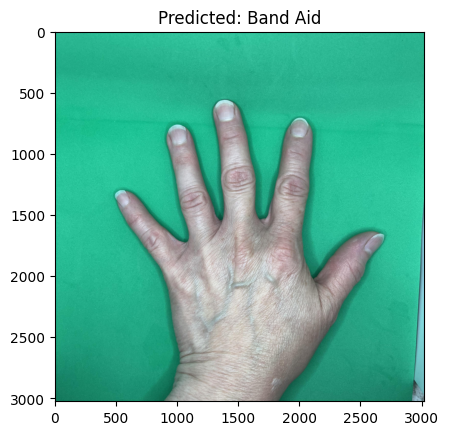

In [12]:
# # Step 3: Load and preprocess an image
# # Download a sample image (e.g., of a dog)
# url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
# response = requests.get(url)
# img = Image.open(BytesIO(response.content))

# Apply the preprocessing transforms and add a batch dimension
# The model expects a batch of images, so we add a new dimension at index 0.
pred_img = samples[1]
input_batch = preprocess(pred_img).unsqueeze(0)

# Step 4: Run inference
with torch.no_grad(): # Disable gradient calculations for faster inference
    prediction = model(input_batch).squeeze(0).softmax(0)

# Step 5: Post-process and print the prediction
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]

print(f"Prediction: {category_name}")
print(f"Confidence: {100 * score:.1f}%")

# Optional: Display the image
plt.imshow(pred_img)
plt.title(f"Predicted: {category_name}")
plt.show()

In [ ]:
model.fc = torch.nn.Sequential(
    torch.nn.Linear(
        in_features=2048,
        out_features=1
    ),
    torch.nn.Sigmoid()
)

In [ ]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

### Perform Inference

### Previous Training

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_data=(x_test, y_test))

In [ ]:
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest MAE: {test_mae}')

In [ ]:
plt.plot(history.history['mae'], label='MAE')
plt.plot(history.history['val_mae'], label = 'val_MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend(loc='lower right')
plt.show()

In [ ]:
model.summary()